# 05a – Tuned random forest: Secondary Mushroom

**Worked on by:** Andreas Schellekens (search space, threshold choice, label-noise experiment, test evaluation, deployable pipeline)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` to `04_model_automl.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

PyCaret (notebook 04) showed that the random forest is the best model family for this data, but its automatic tuning made the forest *worse*, because its search space only allows shallow trees. In this notebook we tune the forest with a search space we choose ourselves and, just as important, choose the **decision threshold** so that the model catches most poisonous mushrooms.

Imports, paths and constants as in the other model notebooks. `LOKY_MAX_CPU_COUNT` silences a harmless joblib warning on Windows and must be set before scikit-learn is imported. `RECALL_TARGET` is the share of poisonous mushrooms the model must catch; section 5 explains the choice.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import randint
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
PREPROCESSOR_PATH = MODEL_DIR / "mushroom_preprocessor.joblib"
MODEL_PATH = MODEL_DIR / "mushroom_random_forest.joblib"
MODEL_INFO_PATH = MODEL_DIR / "mushroom_random_forest.json"
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "05a_model_random_forest"
RANDOM_STATE = 42
TARGET = "is_poisonous"
RECALL_TARGET = 0.90
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}  # same colours as the EDA


def data_path(split, kind):
    # Files made by 02_data_preparation.ipynb, e.g. Data/validation/mushroom_prepared_validation.csv
    return DATA_DIR / split / f"mushroom_{kind}_{split}.csv"

We load the prepared train, validation and test sets from `02_data_preparation.ipynb` (imputed, `log1p` + standardised, one-hot encoded: 64 features), each from its own folder, and use the same 3500 / 750 / 750 split as every other model notebook:
- **train**: the hyperparameter search (5-fold cross-validation inside train) and the final fit;
- **validation**: checking the tuned model and choosing the decision threshold;
- **test**: the final evaluation, once.

The features are converted to plain NumPy arrays (`to_numpy()`) right away. The reason is deployment, as in notebook 03: the saved preprocessor outputs a NumPy array, so the model must be trained on the same kind of input to sit directly behind it in one pipeline (section 8). For a random forest, standardising and `log1p` change nothing: a tree only looks at the *order* of the values, and both transformations keep the order.

In [2]:
prepared = {split: pd.read_csv(data_path(split, "prepared"), index_col="row_id") for split in ["train", "validation", "test"]}
X_train, y_train = prepared["train"].drop(columns=TARGET).to_numpy(), prepared["train"][TARGET]
X_val, y_val = prepared["validation"].drop(columns=TARGET).to_numpy(), prepared["validation"][TARGET]
X_test, y_test = prepared["test"].drop(columns=TARGET).to_numpy(), prepared["test"][TARGET]

print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Share poisonous – train: {y_train.mean():.1%}  |  validation: {y_val.mean():.1%}  |  test: {y_test.mean():.1%}")

Train: (3500, 64)  |  Validation: (750, 64)  |  Test: (750, 64)
Share poisonous – train: 37.9%  |  validation: 37.9%  |  test: 37.9%


## 2. Why a random forest?

A random forest is a collection of decision trees. Each tree is trained on a **bootstrap sample** (rows drawn at random with replacement) and, at every split, may only choose from a **random subset of the features**. Every tree is therefore a bit different, and the forest's probability is the share of trees that vote *poisonous*.

Why this model for this data:
- **It was the best model in PyCaret** (CV AUC 0.831, notebook 04), ahead of LightGBM (0.816) and extra trees (0.797).
- **It combines features.** The EDA showed that no single feature decides edibility; a tree can express combinations like "small cap **and** thin stem **and** woods". That is what lifted the AUC from 0.70 (logistic regression, notebook 03) to 0.83.
- **It is robust against label noise.** About 2% of the labels look flipped (EDA section 9). A deep tree memorises such rows, but only in a small leaf, and only the trees whose bootstrap sample contains the row are affected. Averaging hundreds of trees dilutes these mistakes. This is why deep trees work here, and why PyCaret's shallow trees did not.
- **It needs almost no preprocessing** and gives probabilities, which we need for the threshold (section 5) and for the web interface.

**Paths not taken:**
- *A single decision tree*: easy to explain, but one deep tree memorises the noise and a shallow one is too simple (PyCaret: AUC 0.67).
- *Extra trees* (even more random splits): scored lower than the random forest in PyCaret (0.80), so we do not tune both.
- *Gradient boosting* is the other strong tree ensemble; it gets its own notebook (`05b_model_gradient_boosting.ipynb`).

## 3. Reference: the default forest

Before tuning, we score scikit-learn's default random forest (100 fully grown trees, `max_features="sqrt"`) with the same 5-fold stratified cross-validation as notebooks 02–04. Every tuned version has to beat this number. The metric is **ROC-AUC**, for the reason given in notebook 04: it measures how well the model *ranks* poisonous mushrooms above edible ones, over all thresholds. Recall is set afterwards with the threshold (section 5).

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

default_scores = cross_validate(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                                X_train, y_train, cv=cv, scoring="roc_auc")["test_score"]
default_auc = default_scores.mean()
print(f"Default random forest – CV ROC-AUC: {default_auc:.3f} ± {default_scores.std():.3f}")

Default random forest – CV ROC-AUC: 0.832 ± 0.004


## 4. Hyperparameter search

We search over the hyperparameters that control how detailed and how diverse the trees are. Unlike PyCaret, the space includes **fully grown trees** and very small leaves.

| Hyperparameter | Values tried | What it controls |
|---|---|---|
| `n_estimators` | 300, 500, 800 | Number of trees. More trees never overfit; they only make the average more stable (and the model bigger and slower). |
| `max_depth` | unlimited (`None`), 30, 20, 12 | How deep a tree may grow. PyCaret only allowed 1–11. |
| `min_samples_leaf` | 1 to 10 | Minimum number of training rows in a leaf. Higher = smoother trees that memorise less. |
| `max_features` | `sqrt` (8 of 64), `log2` (6), 20%, 30%, 40%, 50% | Features a split may choose from. Fewer = more diverse trees, more = stronger single trees. |
| `max_samples` | all rows (`None`), 50%, 70%, 90% | Size of each bootstrap sample. Smaller = more diverse trees. |
| `class_weight` | none, `balanced`, `balanced_subsample` | Extra weight for the poisonous class (`subsample`: the weights are recomputed for every bootstrap sample). |
| `criterion` | `gini`, `entropy` | How the quality of a split is measured. |

**Random search instead of grid search.** All combinations together are 17,280 forests, each trained 5 times. `RandomizedSearchCV` tries 40 random combinations instead. Usually only a few hyperparameters really matter, and random search covers the values of each of them well with far fewer fits (Bergstra & Bengio, 2012). Every combination is scored with the same 5 folds on the training set, on ROC-AUC. At the end, the best combination is refitted on all 3500 training rows.

The trees of one forest are built in parallel (`n_jobs=-1` in the forest), the combinations one after the other (`n_jobs=1` in the search). This takes about 2–3 minutes.

In [4]:
search_space = {
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 30, 20, 12],
    "min_samples_leaf": randint(1, 11),
    "max_features": ["sqrt", "log2", 0.2, 0.3, 0.4, 0.5],
    "max_samples": [None, 0.5, 0.7, 0.9],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "criterion": ["gini", "entropy"],
}
search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), search_space, n_iter=40,
                            scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=1)
search.fit(X_train, y_train)

results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
results = results[[f"param_{p}" for p in search_space] + ["mean_test_score", "std_test_score"]]
results.columns = results.columns.str.removeprefix("param_")
print(f"Best CV ROC-AUC: {search.best_score_:.3f}  (default forest: {default_auc:.3f})")
results.head(10).round(4)

Best CV ROC-AUC: 0.837  (default forest: 0.832)


,n_estimators,max_depth,min_samples_leaf,max_features,max_samples,class_weight,criterion,mean_test_score,std_test_score
32,800,None,1,sqrt,0.9,balanced_subsample,gini,0.8375,0.0050
21,800,30,3,0.3,None,balanced_subsample,entropy,0.8375,0.0044
36,500,30,2,0.4,0.9,None,gini,0.8373,0.0059
8,500,30,2,sqrt,0.9,balanced_subsample,gini,0.8372,0.0047
19,300,None,3,0.2,None,balanced_subsample,gini,0.8358,0.0036
24,500,20,2,0.5,0.9,balanced_subsample,gini,0.8354,0.0049
15,800,20,3,sqrt,0.9,balanced_subsample,gini,0.8284,0.0058
23,300,20,4,0.4,0.7,None,gini,0.8278,0.0075
0,800,None,5,0.2,0.9,balanced_subsample,entropy,0.8277,0.0043
25,500,None,4,0.4,0.5,None,entropy,0.8272,0.0052


The table only shows the winners. To see **which hyperparameters matter**, we plot the CV score of all 40 combinations against the three hyperparameters that control how detailed the trees are. Each dot is one combination; the dashed line is the default forest.

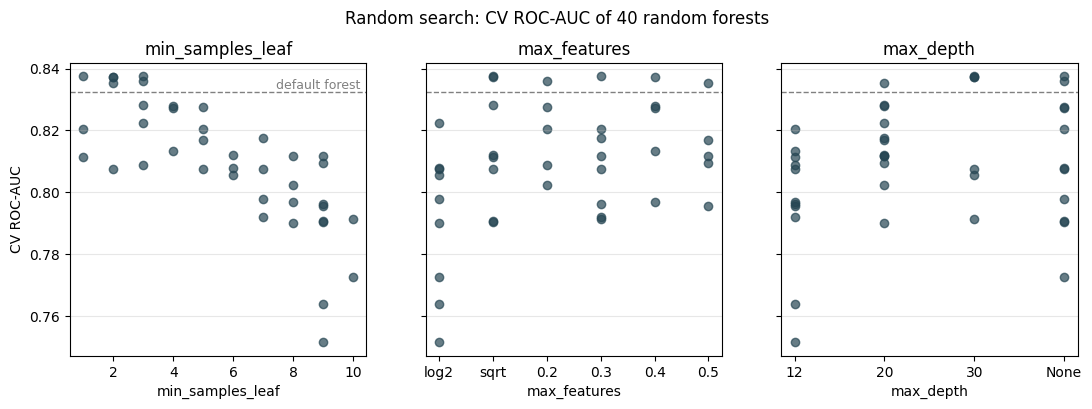

Chosen hyperparameters: {'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.9, 'min_samples_leaf': 1, 'n_estimators': 800}


In [5]:
panels = {
    "min_samples_leaf": None,  # numeric axis
    "max_features": ["log2", "sqrt", "0.2", "0.3", "0.4", "0.5"],  # from few to many features per split
    "max_depth": ["12", "20", "30", "None"],  # from shallow to unlimited
}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (param, order) in zip(axes, panels.items()):
    values = results[param].astype(str)
    x = results[param].astype(float) if order is None else values.map({v: i for i, v in enumerate(order)})
    ax.scatter(x, results["mean_test_score"], s=36, color="#264653", alpha=0.7)
    ax.axhline(default_auc, color="gray", ls="--", lw=1)
    if order is not None:
        ax.set_xticks(range(len(order)), order)
    ax.set(title=param, xlabel=param)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("CV ROC-AUC")
axes[0].text(0.98, default_auc, "default forest", transform=axes[0].get_yaxis_transform(),
             ha="right", va="bottom", color="gray", fontsize=9)
fig.suptitle("Random search: CV ROC-AUC of 40 random forests", y=1.02)
plt.show()

print("Chosen hyperparameters:", search.best_params_)

**Interpretation**
- The best forest scores a CV AUC of **0.837**, 0.005 above the default forest (0.832). The six best combinations all score between 0.835 and 0.838, and the two best are a tie: fully grown trees with leaves of 1 row and `sqrt` features, and trees of depth 30 with leaves of 3 rows and 30% of the features. So there is no single "magic" setting: many detailed forests are equally good, and the default forest is already close.
- **Leaf size matters most.** Leaves of 1–3 rows score best; from about 6 rows on, the AUC drops steadily, to 0.75–0.80 at 9–10 rows. This confirms the lesson of notebook 04: this data needs detailed trees, and the averaging over many trees takes care of the noise.
- **Depth:** a limit of 12 levels (close to PyCaret's space) is clearly worse; 20, 30 and unlimited are equivalent. With 3500 rows a tree hardly ever needs more than 30 levels, so `max_depth=30` is unlimited in practice.
- **Features per split:** only `log2` (6 of 64 columns) is clearly worse. Most of our 64 columns are one-hot columns of rare categories; with only 6 random candidates a split often has no useful feature to choose from. From `sqrt` (8) up to 50% (32) all values reach the top.
- The chosen forest uses `balanced_subsample` class weights and `gini`. Both matter little for the AUC (the top 10 contains forests with and without class weights, and both criteria): class weights mainly shift the probabilities, which the threshold does anyway (notebook 03).
- **Caveat:** the best of 40 CV scores is slightly optimistic, because we picked the maximum of 40 noisy estimates (fold-to-fold standard deviation about 0.005). The validation set (next cell) gives an independent check.

### Does the gain hold up on the validation set?

The search chose the best of 40 combinations on the same 5 folds, so its best CV score is a little optimistic (see the caveat above). The validation set was not involved in the search, so it gives an independent check: we compare the tuned forest (refitted on all 3500 training rows by the search) with the default forest, both scored on the 750 validation mushrooms.

In [6]:
default_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
best_rf = search.best_estimator_  # the best combination, already refitted on all training rows

pd.Series({"default forest": roc_auc_score(y_val, default_rf.predict_proba(X_val)[:, 1]),
           "tuned forest": roc_auc_score(y_val, best_rf.predict_proba(X_val)[:, 1])}, name="validation ROC-AUC").round(3)

default forest    0.811
tuned forest      0.817
Name: validation ROC-AUC, dtype: float64

**Interpretation**
- On the validation set the tuned forest also beats the default forest: AUC 0.817 vs. 0.811, a gain of 0.006, the same size as in cross-validation (0.005). So the gain from tuning is small but real, not an artefact of choosing the best of 40 CV scores.
- Both forests score about 0.02 lower on the validation set than in cross-validation. PyCaret's forest showed the same in notebook 04 (0.818 vs. 0.831). With 750 rows the AUC has a standard error of about 0.015, so one set of 750 mushrooms can easily be a little harder than the average fold. What matters is that the *comparison* between the models agrees.

## 5. Choosing the decision threshold

At the default threshold of 0.5 even a good forest catches only about 60–65% of the poisonous mushrooms (notebook 04). We now choose the threshold ourselves.

**What target?** A missed poisonous mushroom can be deadly; a false alarm costs a meal. So we want a high recall on *poisonous*, but 100% is only possible by calling every mushroom poisonous. Our choice is **90%: the model must catch 9 out of 10 poisonous mushrooms**. The table below shows what 80%, 85% and 95% would cost, so this is a conscious trade-off and easy to change (`RECALL_TARGET` in section 1).

**On which data?** On the **validation set**. The tuned forest, trained on the training rows, predicts the 750 validation mushrooms it has never seen, and on these probabilities we pick the **highest threshold that still reaches the target recall**: the highest such threshold gives the fewest false alarms.
- Why not on the training rows? The forest has almost memorised them: on its own training rows nearly every poisonous mushroom gets a high probability, so a threshold chosen there would be far too high for new mushrooms.
- Why not out-of-fold predictions on train, as in the first version of this notebook? Those come from the same 5 folds that just chose the hyperparameters, which makes them slightly optimistic, and they come from five *other* forests than the one we deploy. The validation probabilities come from exactly the model we deploy, on rows that played no role in any choice so far.
- The price: the validation set has fewer poisonous mushrooms (284) than the training set, so the threshold is a little less precise; one poisonous mushroom more or less moves the recall by 0.35 percentage points. The test set (section 7) shows whether the threshold carries over to new data.

In [7]:
p_val = best_rf.predict_proba(X_val)[:, 1]


def threshold_for_recall(y_true, p, target):
    # Highest threshold whose recall is still >= target (recall only drops when the threshold rises)
    _, recall, thresholds = precision_recall_curve(y_true, p)
    return thresholds[recall[:-1] >= target].max()


def operating_point(y_true, p, threshold):
    pred = p >= threshold
    return {"threshold": threshold, "recall": recall_score(y_true, pred), "precision": precision_score(y_true, pred),
            "share_of_edible_flagged": (pred & (y_true == 0)).sum() / (y_true == 0).sum()}


points = {"default threshold 0.5": operating_point(y_val, p_val, 0.5)}
for target in [0.80, 0.85, 0.90, 0.95]:
    points[f"recall >= {target:.2f}"] = operating_point(y_val, p_val, threshold_for_recall(y_val, p_val, target))
threshold = threshold_for_recall(y_val, p_val, RECALL_TARGET)

print(f"Validation: {y_val.sum()} poisonous of {len(y_val)} mushrooms  |  chosen threshold: {threshold:.3f}")
pd.DataFrame(points).T.round(3)

Validation: 284 poisonous of 750 mushrooms  |  chosen threshold: 0.161


,threshold,recall,precision,share_of_edible_flagged
default threshold 0.5,0.500,0.634,0.796,0.099
recall >= 0.80,0.278,0.803,0.595,0.333
recall >= 0.85,0.225,0.852,0.528,0.464
recall >= 0.90,0.161,0.901,0.461,0.642
recall >= 0.95,0.098,0.951,0.413,0.824


The same trade-off as a picture: how recall and precision on *poisonous* change when the threshold moves. Lowering the threshold means calling more mushrooms poisonous: recall goes up, precision goes down.

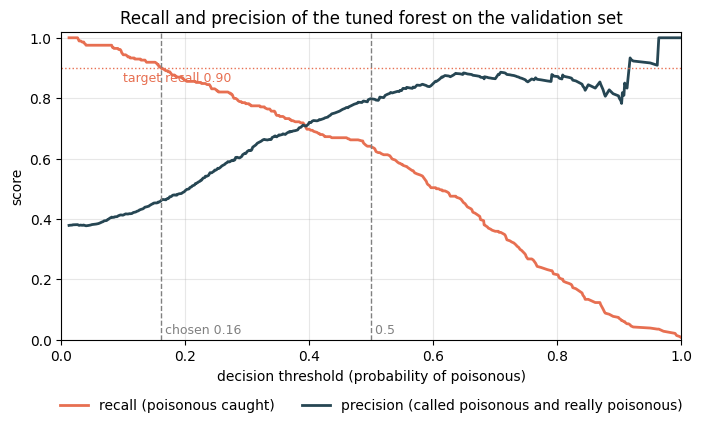

In [8]:
precision, recall, thresholds = precision_recall_curve(y_val, p_val)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, recall[:-1], color=CLASS_PALETTE["poisonous"], lw=2, label="recall (poisonous caught)")
ax.plot(thresholds, precision[:-1], color="#264653", lw=2, label="precision (called poisonous and really poisonous)")
for t, name in [(0.5, "0.5"), (threshold, f"chosen {threshold:.2f}")]:
    ax.axvline(t, color="gray", ls="--", lw=1)
    ax.text(t, 0.02, f" {name}", color="gray", fontsize=9)
ax.axhline(RECALL_TARGET, color=CLASS_PALETTE["poisonous"], ls=":", lw=1)
ax.set(xlabel="decision threshold (probability of poisonous)", ylabel="score", ylim=(0, 1.02), xlim=(0, 1),
       title="Recall and precision of the tuned forest on the validation set")
ax.grid(alpha=0.3)
ax.text(0.1, RECALL_TARGET - 0.01, f"target recall {RECALL_TARGET:.2f}", color=CLASS_PALETTE["poisonous"], fontsize=9, va="top")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.show()

**Interpretation**
- At the default threshold of 0.5, the tuned forest catches 63% of the poisonous validation mushrooms and flags only 10% of the edible ones.
- To catch **90%**, the threshold must drop to **0.16**: a mushroom is called poisonous as soon as about one in six trees says so. The cost: precision falls to 0.46 (more than half of the "poisonous" warnings concern an edible mushroom) and **64% of the edible mushrooms are thrown away**.
- Every extra step of recall is more expensive than the previous one: going from 80% to 85% flags 13 points more edible mushrooms, from 85% to 90% another 18 points, and 95% would mean throwing away 82% of the edible mushrooms. That is what an AUC of about 0.82–0.84 means in practice: with the features we have (and about 2% wrong labels), poisonous and edible mushrooms overlap strongly, and no threshold separates them cleanly.
- **We keep 90%.** For a mushroom advisor the safe default is "don't eat it". The web interface should show the probability as well, so that a user sees the difference between "clearly poisonous" (0.9) and "just above the threshold" (0.2).

## 6. Does removing suspected flipped labels help?

The EDA (section 9) estimated that about 2% of the labels are flipped. An obvious idea: find the training rows whose label a model strongly disagrees with, and drop them or correct their label. We test this, with two rules:

- **Only rows labelled *edible* that look poisonous are touched.** The other direction is dangerous: dropping a row labelled *poisonous* because it looks edible would teach the model that such mushrooms are safe. A false alarm is the cheaper mistake.
- **The cleaning happens inside every CV fold, on the training part only.** The validation part keeps its original labels, so the score still measures how well the model predicts the labels as given. The suspicion itself comes from an *inner* 5-fold CV on the training part: a deep forest has almost memorised its own training rows, so it can only judge rows it has not seen.

We try two strengths (probability of poisonous ≥ 0.9 or ≥ 0.8) and two actions (drop the row or relabel it as poisonous). As scores we use ROC-AUC and the **precision at 90% recall**, our operating point: how many false alarms it costs to catch 9 out of 10 poisonous mushrooms.

To keep the runtime at a few minutes, this experiment uses the chosen hyperparameters with 300 instead of 800 trees; we only compare versions with each other.

**The misleading shortcut, for comparison:** first clean the whole training set, then run the CV. Then the validation folds are cleaned too: the hard rows the model gets wrong have been removed from the exam, so the score goes up without the model getting any better. We add this version to show how large that illusion is.

In [9]:
experiment_rf = clone(best_rf).set_params(n_estimators=300)
y_all = y_train.to_numpy()


def precision_at_recall(y_true, p, target=RECALL_TARGET):
    precision, recall, _ = precision_recall_curve(y_true, p)
    return precision[:-1][recall[:-1] >= target].max()


def suspected_flips(X, y, cutoff, seed):
    # Rows labelled edible that an inner 5-fold CV forest calls poisonous with probability >= cutoff
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    p = cross_val_predict(clone(experiment_rf), X, y, cv=inner_cv, method="predict_proba")[:, 1]
    return (y == 0) & (p >= cutoff)


def make_cleaner(cutoff, action):
    def clean(X, y, seed):
        flags = suspected_flips(X, y, cutoff, seed)
        if action == "drop":
            return X[~flags], y[~flags], flags.sum()
        y = y.copy()
        y[flags] = 1
        return X, y, flags.sum()
    return clean


def fold_scores(X, y, clean=None):
    # 5-fold CV; `clean` changes the training part of every fold, the validation part keeps its labels
    aucs, precisions, changed = [], [], []
    for k, (tr, va) in enumerate(cv.split(X, y)):
        X_tr, y_tr = X[tr], y[tr]
        if clean is not None:
            X_tr, y_tr, n = clean(X_tr, y_tr, seed=k)
            changed.append(n)
        p = clone(experiment_rf).fit(X_tr, y_tr).predict_proba(X[va])[:, 1]
        aucs.append(roc_auc_score(y[va], p))
        precisions.append(precision_at_recall(y[va], p))
    return {"rows_changed_per_fold": np.mean(changed) if changed else 0, "roc_auc": np.mean(aucs),
            f"precision_at_recall_{RECALL_TARGET}": np.mean(precisions)}


noise_results = {"no cleaning": fold_scores(X_train, y_all)}
for cutoff in [0.9, 0.8]:
    for action in ["drop", "relabel"]:
        noise_results[f"{action}, p >= {cutoff}"] = fold_scores(X_train, y_all, make_cleaner(cutoff, action))

# The misleading shortcut: clean all training rows first, then cross-validate on the cleaned data
flags_all = suspected_flips(X_train, y_all, 0.8, seed=RANDOM_STATE)
noise_results["misleading: drop p >= 0.8 before CV"] = fold_scores(X_train[~flags_all], y_all[~flags_all])
noise_results["misleading: drop p >= 0.8 before CV"]["rows_changed_per_fold"] = flags_all.sum() / cv.get_n_splits()

pd.DataFrame(noise_results).T.round(4)

,rows_changed_per_fold,roc_auc,precision_at_recall_0.9
no cleaning,0.0,0.8365,0.5051
"drop, p >= 0.9",3.8,0.8354,0.5030
"relabel, p >= 0.9",3.8,0.8364,0.5070
"drop, p >= 0.8",14.6,0.8375,0.5115
"relabel, p >= 0.8",14.6,0.8366,0.5084
misleading: drop p >= 0.8 before CV,4.0,0.8359,0.5053


**Interpretation**
- **No cleaning variant helps.** All honest versions are within 0.001 AUC and 0.01 precision of "no cleaning", some slightly up and some slightly down: that is noise. Dropping or relabelling about 4 or 15 rows per fold (0.1–0.5% of the training part) changes nothing measurable.
- Why not? First, the forest is already robust against a few flipped labels (section 2): one wrong row only affects a small leaf in some of the trees. Second, the flagged rows are not necessarily errors: many are real edible mushrooms that happen to look like poisonous ones. Removing them removes exactly the hard examples the model has to learn from.
- **The misleading shortcut** removed 20 rows from the whole training set, including the validation folds. On this split it happens to show no gain (AUC 0.836); in the first version of this notebook, with an 80/20 split, the same shortcut removed 43 rows and reported +0.009 AUC, almost as much as the whole gain from tuning. How large the illusion is depends on how many hard rows leave the validation folds, but the method is wrong either way: a validation fold without its hardest rows is an easier exam, not a better model. That is why the cleaning must happen inside the folds.
- **Decision:** we train on all training rows with their original labels.

## 7. Validation & test evaluation

The model is final: the chosen hyperparameters, trained on all 3500 training rows (the refit of the search), with the threshold chosen on the validation set in section 5. Now we evaluate it **once** on the test set, at the default threshold of 0.5 (to compare with notebooks 03 and 04) and at the chosen threshold. The validation rows are listed too, because `07_model_comparison.ipynb` chooses between models on the validation set; at the chosen threshold, the validation recall is 0.90 by construction.

The `evaluate` helper is the same as in notebooks 03 and 04, so the numbers in `metrics.csv` are comparable. It counts `probability ≥ threshold` as poisonous: a forest regularly produces exact ties (e.g. 400 of 800 trees), and a tie goes to the safe side.

In [10]:
def evaluate(name, split, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "split": split,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


p_test = best_rf.predict_proba(X_test)[:, 1]
results = []
for split, y_split, p_split in [("validation", y_val, p_val), ("test", y_test, p_test)]:
    results.append(evaluate("random forest (tuned)", split, y_split, p_split, threshold=0.5))
    results.append(evaluate(f"random forest (tuned, recall {RECALL_TARGET:.2f})", split, y_split, p_split, threshold=threshold))
pd.DataFrame(results).set_index(["model", "split"]).drop(columns="notebook").round(3)

,,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
model,split,,,,,,,,
random forest (tuned),validation,0.500,0.800,0.634,0.796,0.706,0.817,104,46
"random forest (tuned, recall 0.90)",validation,0.161,0.564,0.901,0.461,0.610,0.817,28,299
random forest (tuned),test,0.500,0.795,0.613,0.798,0.693,0.842,110,44
"random forest (tuned, recall 0.90)",test,0.161,0.579,0.930,0.471,0.626,0.842,20,296


The two confusion matrices side by side. Rows are the true class, columns the prediction; the bottom-left cell is the dangerous one (poisonous mushrooms called edible).

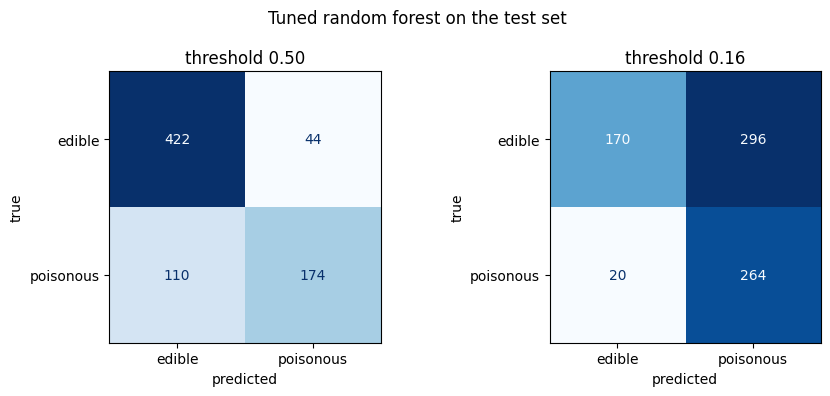

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, t in zip(axes, [0.5, threshold]):
    ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= t).astype(int), display_labels=["edible", "poisonous"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set(title=f"threshold {t:.2f}", xlabel="predicted", ylabel="true")
    ax.grid(False)
fig.suptitle("Tuned random forest on the test set")
plt.tight_layout()
plt.show()

**Interpretation**
- **At threshold 0.5:** test accuracy 0.795, AUC 0.842, recall 0.613, precision 0.798. Compared with PyCaret's default forest on the same test set (notebook 04): AUC 0.838 → 0.842, missed poisonous 112 → 110, false alarms 49 → 44. Tuning helped a little, as the validation set predicted.
- The test AUC (0.842) is higher than the validation AUC (0.817), while cross-validation (0.837) lies in between. Two sets of 750 mushrooms differ by 0.025 in AUC: this shows how noisy a single set of 750 rows is (standard error about 0.015 each). It is also why `07_model_comparison.ipynb` compares models on exactly the same rows, with a bootstrap, instead of comparing single numbers.
- **At threshold 0.16:** recall **0.930** (264 of the 284 poisonous mushrooms caught, **20 missed** instead of 110). That is even more than the 90% chosen on the validation set: the test set is a little easier, so the same threshold catches more. The price: 296 of the 466 edible mushrooms (64%) are flagged, precision is 0.47.
- Accuracy drops from 0.80 to 0.58, below the naive 62%. That is expected and fine: we deliberately trade many false alarms for few missed poisonous mushrooms, and accuracy counts both errors as equally bad. For this model, recall and the number of missed poisonous mushrooms are the numbers that matter.

## 8. Saving the model for deployment

As with the baseline (notebook 03), we save a **pipeline**: the fitted preprocessor from notebook 02 followed by the fitted forest. The API gives it the cleaned, readable columns and gets a probability back. Nothing is refitted here.

Two differences with the baseline:
- **The threshold is part of the model.** `pipeline.predict()` would still use 0.5, so the API must compare the probability with our threshold itself. We store the threshold (and how it was chosen) in a small JSON file next to the model: readable for humans, and readable for an API in any language.
- **Size.** 800 deep trees are much larger than one logistic regression. `compress=3` lets joblib zip the file, which makes it several times smaller (well below GitHub's 100 MB limit) at the cost of slightly slower loading.

**Why not retrain on train + validation before deploying?** The threshold was chosen on the probabilities of *this* forest, trained on these 3500 rows. A forest trained on 4250 rows gives slightly different probabilities, and the threshold would no longer be tested. We deploy exactly the model that was validated and tested.

We check again that the pipeline, fed with the **cleaned** test rows (`Data/test/mushroom_cleaned_test.csv`), gives exactly the same probabilities as the forest on the prepared test set.

In [12]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
assert list(preprocessor.get_feature_names_out()) == list(prepared["test"].drop(columns=TARGET).columns)
deploy_pipeline = Pipeline([("preprocess", preprocessor), ("model", best_rf)])

cleaned_test = pd.read_csv(data_path("test", "cleaned"), index_col="row_id")
assert cleaned_test.index.equals(prepared["test"].index)
assert np.allclose(deploy_pipeline.predict_proba(cleaned_test[list(preprocessor.feature_names_in_)])[:, 1], p_test), \
    "Pipeline output differs"

joblib.dump(deploy_pipeline, MODEL_PATH, compress=3)
model_info = {
    "model": "random forest (tuned)",
    "notebook": NOTEBOOK,
    "threshold": round(float(threshold), 4),
    "threshold_rule": f"highest threshold with recall (poisonous) >= {RECALL_TARGET} on the validation set",
    "cv_roc_auc": round(float(search.best_score_), 4),
    "validation_roc_auc": round(float(roc_auc_score(y_val, p_val)), 4),
    "hyperparameters": {k: v.item() if hasattr(v, "item") else v for k, v in search.best_params_.items()},  # NumPy ints -> plain ints for JSON
    "input_columns": list(preprocessor.feature_names_in_),
}
MODEL_INFO_PATH.write_text(json.dumps(model_info, indent=2))
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)  and  {MODEL_INFO_PATH}")
print(json.dumps(model_info, indent=2))

Saved models\mushroom_random_forest.joblib  (26.5 MB)  and  models\mushroom_random_forest.json
{
  "model": "random forest (tuned)",
  "notebook": "05a_model_random_forest",
  "threshold": 0.1613,
  "threshold_rule": "highest threshold with recall (poisonous) >= 0.9 on the validation set",
  "cv_roc_auc": 0.8375,
  "validation_roc_auc": 0.8168,
  "hyperparameters": {
    "class_weight": "balanced_subsample",
    "criterion": "gini",
    "max_depth": null,
    "max_features": "sqrt",
    "max_samples": 0.9,
    "min_samples_leaf": 1,
    "n_estimators": 800
  },
  "input_columns": [
    "cap_diameter",
    "stem_height",
    "stem_width",
    "has_stem",
    "spore_print_color",
    "gill_color",
    "habitat",
    "season",
    "ring_type",
    "cap_shape",
    "stem_surface"
  ]
}


## 9. Storing the metrics

Both test rows (threshold 0.5 and the chosen threshold) go into the shared `models/metrics.csv`; rows of this notebook are replaced when it is run again.

In [13]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,split,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,gradient boosting (tuned),05b_model_gradient_boosting,validation,0.500,0.799,0.634,0.793,0.705,0.819,104,47
1,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,validation,0.139,0.573,0.901,0.467,0.615,0.819,28,292
2,gradient boosting (tuned),05b_model_gradient_boosting,test,0.500,0.808,0.623,0.827,0.711,0.847,107,37
3,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,test,0.139,0.576,0.940,0.470,0.627,0.847,17,301
4,ensemble (stack: forest + boosting),05c_model_ensemble,validation,0.500,0.801,0.669,0.776,0.718,0.821,94,55
5,"ensemble (stack: forest + boosting), recall 0.90",05c_model_ensemble,validation,0.130,0.575,0.901,0.468,0.616,0.821,28,291
6,ensemble (stack: forest + boosting),05c_model_ensemble,test,0.500,0.811,0.662,0.803,0.726,0.851,96,46
7,"ensemble (stack: forest + boosting), recall 0.90",05c_model_ensemble,test,0.130,0.581,0.923,0.473,0.625,0.851,22,292
8,naive (always edible),03_model_baseline,validation,0.500,0.621,0.000,0.000,0.000,0.500,284,0
9,logistic regression (balanced),03_model_baseline,validation,0.500,0.656,0.623,0.540,0.578,0.704,107,151


## 10. Conclusion & next steps

- **Our own search space works where PyCaret's failed.** CV AUC 0.832 → 0.837, validation AUC 0.811 → 0.817, test AUC **0.842** (PyCaret's default forest: 0.838). The gain is small but consistent on all three. The key is detailed trees: small leaves and no shallow depth limit, the opposite of PyCaret's space.
- **The threshold does the heavy lifting for recall.** With a threshold of 0.16, chosen on the validation set, the forest catches 93% of the poisonous test mushrooms (20 missed, versus 110 at 0.5), at the cost of 296 false alarms out of 466 edible mushrooms.
- **Removing suspected flipped labels does not help** when it is evaluated honestly. We train on all rows.
- **Deployable:** `models/mushroom_random_forest.joblib` (preprocessor + forest) with `models/mushroom_random_forest.json` (threshold 0.161 and how it was chosen). The API must call a mushroom poisonous when its probability is ≥ the threshold, not use `predict()`.

**Next steps**
- `05b_model_gradient_boosting.ipynb`: the other tree ensemble, with the same protocol (own search space, threshold for 90% recall on validation, same test set).
- `05c_model_ensemble.ipynb`: combine models of different families.
- `07_model_comparison.ipynb`: compare all models on the same rows, permutation importance, and an error analysis of the poisonous mushrooms that are still missed.